# 电商销售数据分析项目

## 项目背景
随着电商行业竞争加剧，企业需要通过数据分析了解销售现状、识别增长机会、优化运营策略。本项目基于某电商平台 2024-2025 年的订单数据，从品类、区域、渠道、用户四个维度进行深入分析。

## 核心问题
1. 哪些品类最赚钱？利润结构是否健康？
2. 各区域增长情况如何？哪些区域需要重点关注？
3. 客户结构如何？是否存在流失风险？

## 技术栈
- Python / Pandas / Matplotlib
- RFM 客户分层模型
- Jupyter Notebook

## 一、环境准备与数据读取

In [1]:
# 导入所需库
import pandas as pd
import matplotlib.pyplot as plt

# 设置中文字体，解决中文乱码问题
plt.rcParams['font.sans-serif'] = ['SimHei']  # Windows 用 SimHei，Mac 用 Arial Unicode MS
plt.rcParams['axes.unicode_minus'] = False    # 解决负号显示为方框的问题

In [2]:
# 读取电商订单数据
df = pd.read_csv('data/ecommerce_orders.csv')

# 查看数据基本信息
print(f'数据形状: {df.shape[0]} 行, {df.shape[1]} 列')
print('-' * 50)
df.info()

数据形状: 10000 行, 22 列
--------------------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 22 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   订单号     10000 non-null  str    
 1   订单日期    10000 non-null  str    
 2   发货日期    10000 non-null  str    
 3   客户ID    10000 non-null  str    
 4   客户类型    10000 non-null  str    
 5   区域      10000 non-null  str    
 6   城市      9909 non-null   str    
 7   品类      10000 non-null  str    
 8   子品类     10000 non-null  str    
 9   商品名称    10000 non-null  str    
 10  销售渠道    10000 non-null  str    
 11  支付方式    10000 non-null  str    
 12  数量      10000 non-null  int64  
 13  单价      10000 non-null  float64
 14  销售额     10000 non-null  float64
 15  折扣率     10000 non-null  float64
 16  折扣金额    10000 non-null  float64
 17  最终销售额   10000 non-null  float64
 18  成本      10000 non-null  float64
 19  利润      10000 non-null  float64
 20  订单状态    10000

In [3]:
# 查看前5行，了解字段内容
df.head()

,订单号,订单日期,发货日期,客户ID,客户类型,区域,城市,品类,子品类,商品名称,...,数量,单价,销售额,折扣率,折扣金额,最终销售额,成本,利润,订单状态,评分
0,SO00100001,2024-04-12,2024-04-14,C00434,老客户,华南,佛山,数码,中端,耳机,...,6,3145.86,18875.16,0.00,0.00,18875.16,14393.12,4482.04,已完成,5.0
1,SO00100002,2025-03-11,2025-03-14,C00758,新客户,华南,东莞,家居,入门,窗帘,...,1,613.78,613.78,0.00,0.00,613.78,481.98,131.80,已完成,2.0
2,SO00100003,2024-09-27,2024-09-27,C00234,老客户,东北,大连,图书,中端,传记,...,1,103.81,103.81,0.00,0.00,103.81,41.54,62.27,已完成,3.0
3,SO00100004,2024-04-16,2024-04-21,C00670,老客户,华北,太原,家电,入门,电视,...,3,4937.04,14811.12,0.05,740.56,14070.56,8173.26,6637.86,已完成,4.0
4,SO00100005,2024-03-12,2024-03-12,C00663,老客户,华南,厦门,图书,高端,童书,...,1,107.83,107.83,0.00,0.00,107.83,76.39,31.44,已完成,4.0


## 二、数据清洗

In [4]:
# 2.1 检查缺失值
print('缺失值统计:')
print(df.isnull().sum())

缺失值统计:
订单号        0
订单日期       0
发货日期       0
客户ID       0
客户类型       0
区域         0
城市        91
品类         0
子品类        0
商品名称       0
销售渠道       0
支付方式       0
数量         0
单价         0
销售额        0
折扣率        0
折扣金额       0
最终销售额      0
成本         0
利润         0
订单状态       0
评分       218
dtype: int64


In [5]:
# 2.2 处理缺失值
# 评分缺失用 0 填充（代表未评分）
df['评分'] = df['评分'].fillna(0)

# 城市缺失用 "未知" 填充
df['城市'] = df['城市'].fillna('未知')

# 确认缺失值已处理完毕
df.isnull().sum()

订单号      0
订单日期     0
发货日期     0
客户ID     0
客户类型     0
区域       0
城市       0
品类       0
子品类      0
商品名称     0
销售渠道     0
支付方式     0
数量       0
单价       0
销售额      0
折扣率      0
折扣金额     0
最终销售额    0
成本       0
利润       0
订单状态     0
评分       0
dtype: int64

In [6]:
# 2.3 日期类型转换
df['订单日期'] = pd.to_datetime(df['订单日期'])
df['发货日期'] = pd.to_datetime(df['发货日期'])

# 提取年份、月份，便于后续做时间序列分析
df['年份'] = df['订单日期'].dt.year
df['月份'] = df['订单日期'].dt.month

print(f'日期范围: {df["订单日期"].min()} ~ {df["订单日期"].max()}')

日期范围: 2024-01-01 00:00:00 ~ 2025-12-30 00:00:00


In [7]:
# 2.4 筛选已完成的订单
# 排除退款、取消等异常订单，只保留正常完成的订单用于分析
df_clean = df[df['订单状态'] == '已完成'].copy()

print(f'清洗前行数: {len(df)}')
print(f'清洗后行数: {len(df_clean)}')
print(f'已完成订单占比: {len(df_clean)/len(df):.1%}')

清洗前行数: 10000
清洗后行数: 8544
已完成订单占比: 85.4%


## 三、探索性分析（EDA）

In [8]:
# 3.1 总体概况：核心经营指标
total_sales = df_clean['最终销售额'].sum()
total_profit = df_clean['利润'].sum()
total_orders = df_clean['订单号'].nunique()
avg_order_value = total_sales / total_orders

print(f'总销售额: {total_sales:,.0f} 元')
print(f'总利润: {total_profit:,.0f} 元')
print(f'总订单数: {total_orders}')
print(f'平均客单价: {avg_order_value:,.0f} 元')
print(f'整体利润率: {total_profit/total_sales:.1%}')

总销售额: 24,192,562 元
总利润: 9,302,141 元
总订单数: 8544
平均客单价: 2,832 元
整体利润率: 38.5%


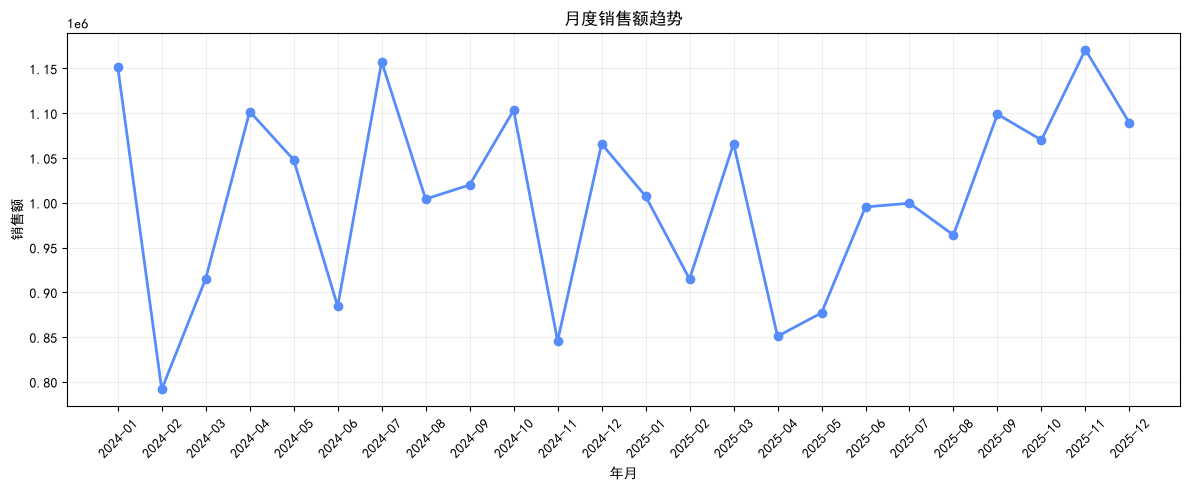

In [9]:
# 3.2 月度销售趋势
monthly = df_clean.groupby(['年份', '月份'])['最终销售额'].sum().reset_index()
monthly['年月'] = monthly['年份'].astype(str) + '-' + monthly['月份'].astype(str).str.zfill(2)

plt.figure(figsize=(12, 5))
plt.plot(monthly['年月'], monthly['最终销售额'], marker='o', linewidth=2)
plt.title('月度销售额趋势')
plt.xlabel('年月')
plt.ylabel('销售额')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

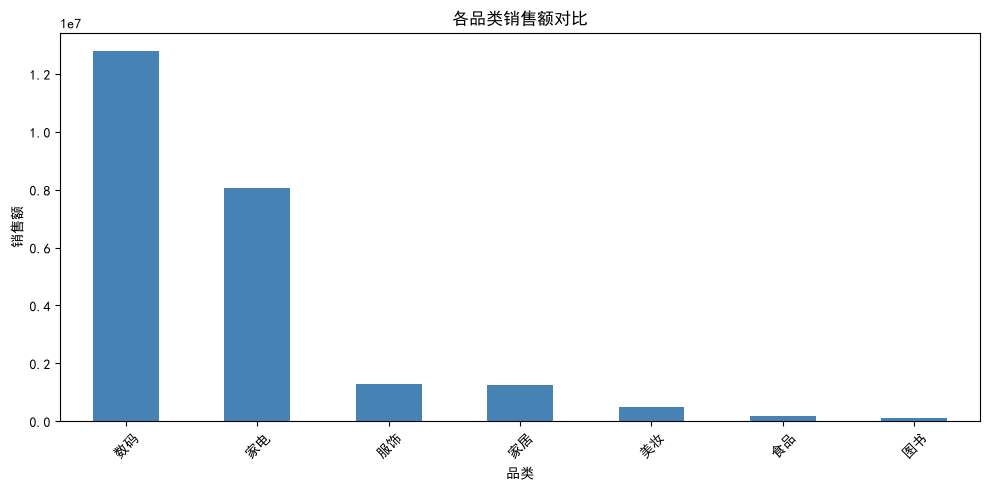

In [10]:
# 3.3 各品类销售额对比
category_sales = df_clean.groupby('品类')['最终销售额'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
category_sales.plot(kind='bar', color='steelblue')
plt.title('各品类销售额对比')
plt.xlabel('品类')
plt.ylabel('销售额')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

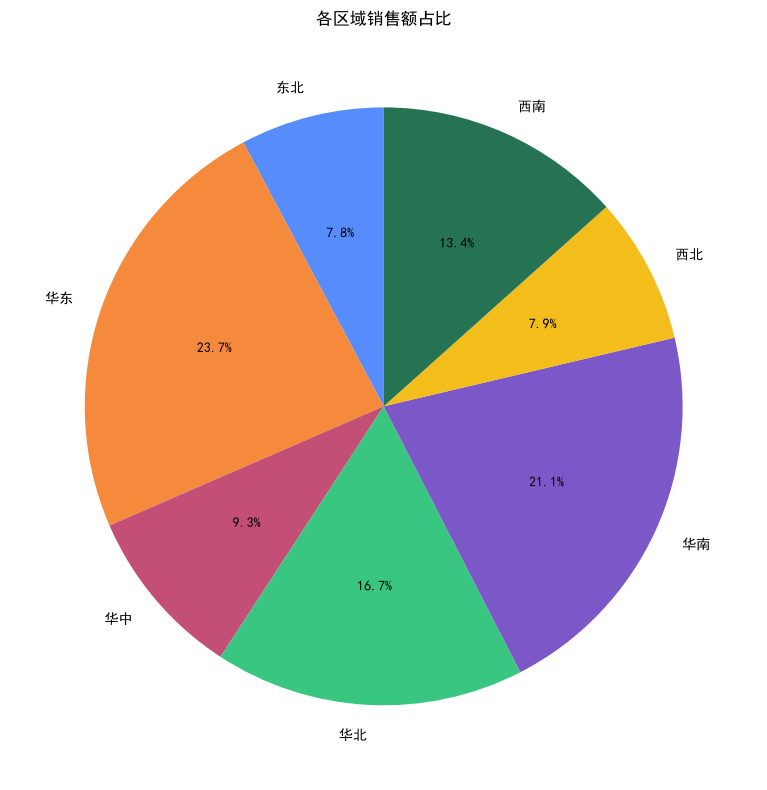

In [11]:
# 3.4 各区域销售额占比
region_sales = df_clean.groupby('区域')['最终销售额'].sum()

plt.figure(figsize=(8, 8))
plt.pie(region_sales, labels=region_sales.index, autopct='%1.1f%%', startangle=90)
plt.title('各区域销售额占比')
plt.tight_layout()
plt.show()

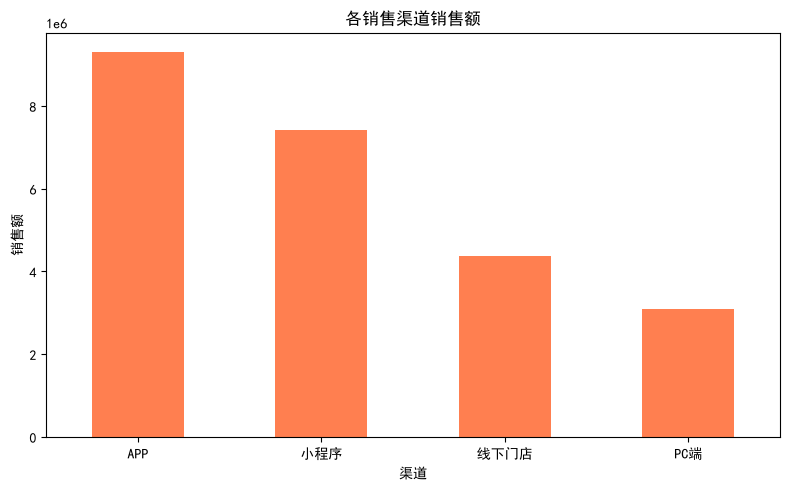

In [12]:
# 3.5 各销售渠道销售额
channel_sales = df_clean.groupby('销售渠道')['最终销售额'].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
channel_sales.plot(kind='bar', color='coral')
plt.title('各销售渠道销售额')
plt.xlabel('渠道')
plt.ylabel('销售额')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 四、深入分析

### 业务问题 1：哪些品类最赚钱？利润结构是否健康？

In [13]:
# 按品类汇总销售额、利润、订单数
category_analysis = df_clean.groupby('品类').agg(
    销售额=('最终销售额', 'sum'),
    利润=('利润', 'sum'),
    订单数=('订单号', 'count')
).sort_values('利润', ascending=False)

# 计算利润率和利润占比
category_analysis['利润率'] = category_analysis['利润'] / category_analysis['销售额']
category_analysis['利润占比'] = category_analysis['利润'] / category_analysis['利润'].sum()

category_analysis[['销售额', '利润', '利润率', '利润占比']].round(2)

,销售额,利润,利润率,利润占比
品类,,,,
数码,12786248.50,4971745.53,0.39,0.53
家电,8062672.19,3041672.58,0.38,0.33
服饰,1274493.67,493978.31,0.39,0.05
家居,1267796.16,489450.32,0.39,0.05
美妆,495203.91,188168.14,0.38,0.02
食品,196082.63,74372.82,0.38,0.01
图书,110064.99,42753.45,0.39,0.00


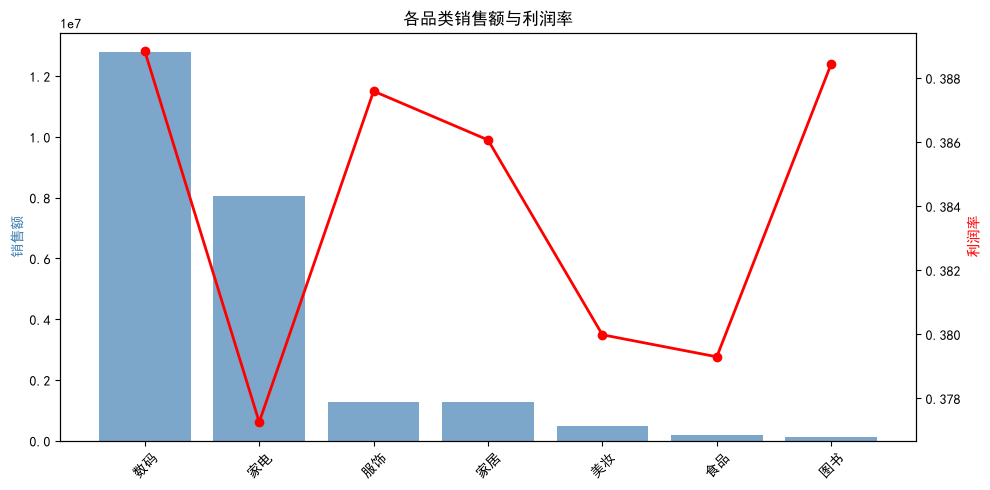

In [14]:
# 可视化：各品类销售额与利润率（双轴图）
fig, ax1 = plt.subplots(figsize=(10, 5))

# 左轴：销售额（柱状图）
ax1.bar(category_analysis.index, category_analysis['销售额'], color='steelblue', alpha=0.7, label='销售额')
ax1.set_ylabel('销售额', color='steelblue')
ax1.tick_params(axis='x', rotation=45)

# 右轴：利润率（折线图）
ax2 = ax1.twinx()
ax2.plot(category_analysis.index, category_analysis['利润率'], color='red', marker='o', linewidth=2, label='利润率')
ax2.set_ylabel('利润率', color='red')

plt.title('各品类销售额与利润率')
plt.tight_layout()
plt.show()

**发现**：
- 数码和家电合计贡献了 **86% 的利润**，是绝对的利润支柱
- 各品类利润率接近（38%-39%），利润差异主要由销售额规模决定
- 服饰、家居利润率不低但销售额过小，增长潜力未释放

### 业务问题 2：各区域增长情况如何？哪些区域需要重点关注？

In [15]:
# 按区域+年份汇总销售额
region_year = df_clean.groupby(['区域', '年份'])['最终销售额'].sum().unstack()

# 计算 2025 年相对 2024 年的同比增长率
region_year['增长率'] = (region_year[2025] - region_year[2024]) / region_year[2024]
region_year = region_year.sort_values('增长率', ascending=False)

region_year.round(2)

年份,2024,2025,增长率
区域,,,
华南,2343780.08,2768320.94,0.18
华东,2743352.15,3001697.70,0.09
华北,2061975.09,1988967.86,-0.04
西南,1702827.48,1533877.40,-0.10
东北,999450.90,882582.56,-0.12
华中,1202165.13,1044644.60,-0.13
西北,1035225.26,883694.90,-0.15


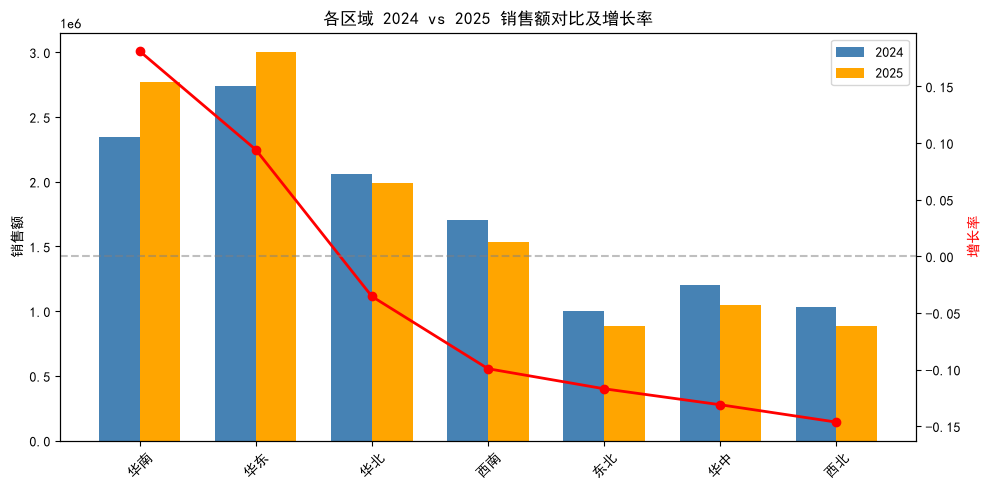

In [16]:
# 可视化：各区域 2024 vs 2025 销售额对比及增长率
fig, ax1 = plt.subplots(figsize=(10, 5))

x = range(len(region_year.index))
width = 0.35

# 左轴：两年销售额对比（分组柱状图）
ax1.bar([i - width/2 for i in x], region_year[2024], width, label='2024', color='steelblue')
ax1.bar([i + width/2 for i in x], region_year[2025], width, label='2025', color='orange')
ax1.set_xticks(x)
ax1.set_xticklabels(region_year.index, rotation=45)
ax1.set_ylabel('销售额')
ax1.legend()

# 右轴：增长率（折线图）
ax2 = ax1.twinx()
ax2.plot(x, region_year['增长率'], color='red', marker='o', linewidth=2)
ax2.set_ylabel('增长率', color='red')
ax2.axhline(y=0, color='gray', linestyle='--', alpha=0.5)  # 0 增长基准线

plt.title('各区域 2024 vs 2025 销售额对比及增长率')
plt.tight_layout()
plt.show()

**发现**：
- 仅 **华南（+18%）和华东（+9%）** 两个区域实现正增长
- 其余 5 个区域全部下滑，**西北下滑最严重（-15%）**
- 区域增长分化严重，增长引擎集中在南方

### 业务问题 3：客户结构如何？是否存在流失风险？（RFM 分析）

In [17]:
# RFM 模型：对客户进行价值分层
# R (Recency)  : 最近一次消费距今天数，越小越好
# F (Frequency): 消费频次（订单数），越大越好
# M (Monetary) : 消费总金额，越大越好

max_date = df_clean['订单日期'].max()  # 以数据中最大日期作为基准

rfm = df_clean.groupby('客户ID').agg({
    '订单日期': lambda x: (max_date - x.max()).days,  # R：距最近消费的天数
    '订单号': 'count',                                 # F：消费频次
    '最终销售额': 'sum'                                # M：消费总金额
}).rename(columns={'订单日期': 'R', '订单号': 'F', '最终销售额': 'M'})

rfm.head()

,R,F,M
客户ID,,,
C00001,225,10,18520.22
C00002,69,10,19463.50
C00003,15,10,26419.59
C00004,0,9,33276.78
C00005,39,10,23564.54


In [18]:
# 对 RFM 三个维度分别打分（1-5 分）
# R 越小分越高（最近消费的客户更有价值）
rfm['R_score'] = pd.qcut(rfm['R'], 5, labels=[5, 4, 3, 2, 1])
# F 和 M 越大分越高
rfm['F_score'] = pd.qcut(rfm['F'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5])
rfm['M_score'] = pd.qcut(rfm['M'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5])

# 定义客户分层规则
def rfm_label(row):
    r, f, m = int(row['R_score']), int(row['F_score']), int(row['M_score'])
    if r >= 4 and f >= 4 and m >= 4:
        return '重要价值客户'      # 最近消费、频次高、金额高
    elif r >= 4 and f < 4 and m >= 4:
        return '重要发展客户'      # 最近消费、金额高但频次低
    elif r < 4 and f >= 4 and m >= 4:
        return '重要保持客户'      # 频次高、金额高但很久没来
    elif r < 4 and f < 4 and m >= 4:
        return '重要挽留客户'      # 金额高但久未消费，流失风险高
    else:
        return '一般客户'

rfm['客户分层'] = rfm.apply(rfm_label, axis=1)
rfm.head()

,R,F,M,R_score,F_score,M_score,客户分层
客户ID,,,,,,,
C00001,225,10,18520.22,1,2,2,一般客户
C00002,69,10,19463.50,2,2,2,一般客户
C00003,15,10,26419.59,5,2,3,一般客户
C00004,0,9,33276.78,5,2,4,重要发展客户
C00005,39,10,23564.54,3,2,3,一般客户


In [19]:
# 统计各分层客户数量
segment_counts = rfm['客户分层'].value_counts()
print('客户分层统计:')
print(segment_counts)
print(f'\n总客户数: {len(rfm)}')
print(f'高价值客户占比: {(len(rfm)-segment_counts["一般客户"])/len(rfm):.1%}')

客户分层统计:
客户分层
一般客户      479
重要价值客户    105
重要挽留客户     87
重要保持客户     83
重要发展客户     45
Name: count, dtype: int64

总客户数: 799
高价值客户占比: 40.1%


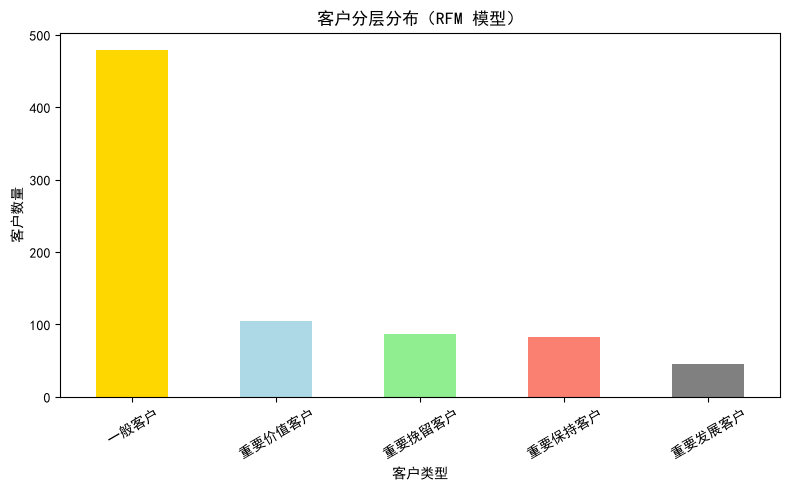

In [20]:
# 可视化：客户分层分布
colors = ['gold', 'lightblue', 'lightgreen', 'salmon', 'gray']
plt.figure(figsize=(8, 5))
segment_counts.plot(kind='bar', color=colors)
plt.title('客户分层分布（RFM 模型）')
plt.xlabel('客户类型')
plt.ylabel('客户数量')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

**发现**：
- 一般客户占比近 **60%**，客户结构偏初级
- 高价值客户合计仅占 **41.5%**
- 87 个 "重要挽留客户" 消费金额高但久未复购，存在流失风险

## 五、结论与建议

### 结论一：品类高度集中，抗风险能力弱
数码和家电两个品类贡献了 86% 的利润，品类结构过度集中，抗风险能力不足。

**建议**：
- 加大服饰、家居品类的资源投入（利润率 39%，有增长潜力）
- 评估美妆、食品、图书的战略定位，考虑整合或优化

### 结论二：区域增长分化严重，5 个区域持续下滑
仅华南和华东实现增长，其余 5 个区域全部负增长，西北下滑最严重（-15%）。

**建议**：
- **复制华南模式**：总结华南 +18% 增长的成功经验，推广至其他区域
- **西北专项攻坚**：深入分析西北下滑原因，制定针对性止损方案
- **华北稳住基本盘**：华北基数大（200 万+）但在下滑，优先止跌

### 结论三：客户结构偏初级，高价值客户流失风险高
一般客户占 58.5%，高价值客户占比低，且有 87 个高价值客户正在流失。

**建议**：
- **挽留高价值客户**：对 87 个"重要挽留客户"推送专属权益，降低流失率
- **培育发展客户**：对 45 个"重要发展客户"推送复购提醒，提升消费频次
- **一般客户升级**：通过会员积分、满减活动引导一般客户向高价值转化